In [113]:
# solving logistic regression using gradient regression

In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

In [115]:
X, y = make_classification(n_samples= 100, n_features= 2, n_informative= 1, n_redundant= 0, n_classes= 2, n_clusters_per_class= 1,
                           random_state= 41, class_sep= 20, hypercube= False)

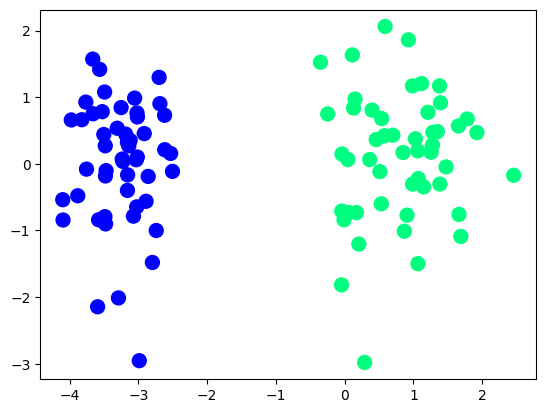

In [116]:
plt.scatter(X[:, 0], X[:, 1], c = y, cmap= 'winter', s = 100)
plt.show()

In [117]:
from sklearn.linear_model import LogisticRegression

In [118]:
lg = LogisticRegression(solver= 'sag',penalty= None)

In [119]:
lg.fit(X, y)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(penalty=None, solver='sag')

In [120]:
lg.intercept_

array([5.76461627])

In [121]:
lg.coef_

array([[4.79510153, 0.21340819]])

In [122]:
m1 = -(lg.coef_[0][0] / lg.coef_[0][1])
b1 = -(lg.intercept_ / lg.coef_[0][1])

In [129]:
from scipy.special import expit

In [135]:
def logistic_reg(X, y):

  X = np.insert(X, 0, 1, axis = 1)
  w = np.ones(X.shape[1])
  lr = 0.1

  for i in range(2500):
    y_hat = expit(np.dot(X, w))
    w = w + lr * (np.dot(y - y_hat, X) / X.shape[0])
  return w[0], w[1:]

In [136]:
int2,coeff2 = logistic_reg(X, y)

In [137]:
m2 = -(coeff2[0] / coeff2[1])
b2 = -(int2 / coeff2[1])

In [138]:
X_input = np.linspace(-3, 3, 100)
y_reg_sc = m1* X_input + b1
y_reg_own = m2 * X_input + b2

(-3.0, 2.0)

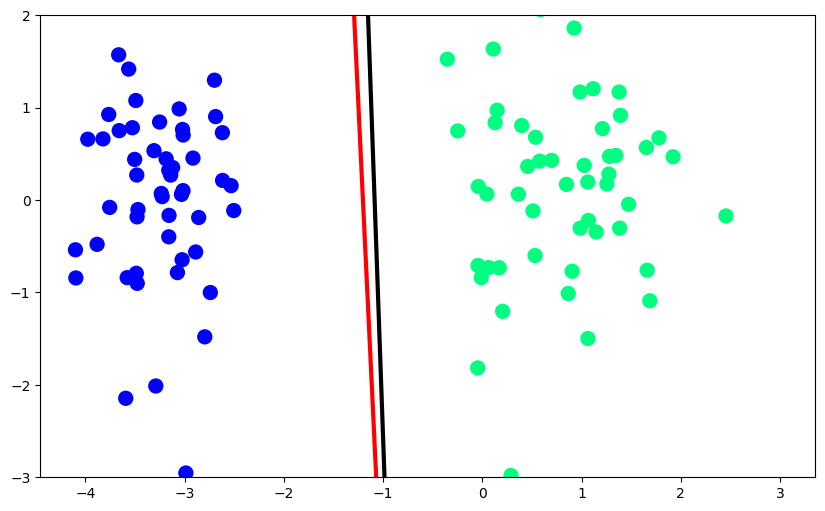

In [142]:
plt.figure(figsize= (10, 6))
plt.plot(X_input, y_reg_sc, color = 'red', linewidth = 3)
plt.plot(X_input, y_reg_own, color = 'black', linewidth = 3)
plt.scatter(X[:, 0], X[:, 1], c = y, cmap = 'winter', s = 100)
plt.ylim(-3, 2)